In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import StandardScaler

In [2]:
train = pd.read_csv("../dataset/pre_processed/train_preprocessed.csv")
test = pd.read_csv("../dataset/pre_processed/test_preprocessed.csv")

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,4.110874,RL,65.0,8450.0,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500.0
1,2,3.044522,RL,80.0,9600.0,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500.0
2,3,4.110874,RL,68.0,11250.0,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500.0
3,4,4.262680,RL,60.0,9550.0,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,0,0,2,2006,WD,Abnorml,140000.0
4,5,4.110874,RL,84.0,14260.0,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000.0


In [4]:
train["TotalSF"] = (
    train["TotalBsmtSF"] +
    train["1stFlrSF"] +
    train["2ndFlrSF"]
)

test["TotalSF"] = (
    test["TotalBsmtSF"] +
    test["1stFlrSF"] +
    test["2ndFlrSF"]
)

In [5]:
train["HouseAge"] = (
    train["YrSold"] -
    train["YearBuilt"]
)

test["HouseAge"] = (
    test["YrSold"] -
    test["YearBuilt"]
)

In [6]:
train["RemodelAge"] = (
    train["YrSold"] -
    train["YearRemodAdd"]
)

test["RemodelAge"] = (
    test["YrSold"] -
    test["YearRemodAdd"]
)

In [7]:
train["TotalBath"] = (
    train["FullBath"] +
    (0.5 * train["HalfBath"]) +
    train["BsmtFullBath"] +
    (0.5 * train["BsmtHalfBath"])
)

test["TotalBath"] = (
    test["FullBath"] +
    (0.5 * test["HalfBath"]) +
    test["BsmtFullBath"] +
    (0.5 * test["BsmtHalfBath"])
)

In [8]:
train["TotalPorchSF"] = (
    train["OpenPorchSF"] +
    train["EnclosedPorch"] +
    train["3SsnPorch"] +
    train["ScreenPorch"]
)

test["TotalPorchSF"] = (
    test["OpenPorchSF"] +
    test["EnclosedPorch"] +
    test["3SsnPorch"] +
    test["ScreenPorch"]
)

In [9]:
numerical_columns = train.select_dtypes(include=["int64","float64"]).columns

numerical_columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'TotalSF', 'HouseAge',
       'RemodelAge', 'TotalBath', 'TotalPorchSF'],
      dtype='str')

In [10]:
categorical_column = train.select_dtypes(include="object").columns

categorical_column

C:\Users\Dell\AppData\Local\Temp\ipykernel_13712\1398324780.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_column = train.select_dtypes(include="object").columns


Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [11]:
train.isnull().sum().sum()

np.int64(0)

## One Hot encoding

In [12]:
train = pd.get_dummies(train, drop_first=True, dtype = int)

In [13]:
train

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,4.110874,65.0,8450.0,7,5.0,2003,2003,5.283204,706.0,...,0,0,0,0,1,0,0,0,1,0
1,2,3.044522,80.0,9600.0,6,7.5,1976,1976,0.000000,978.0,...,0,0,0,0,1,0,0,0,1,0
2,3,4.110874,68.0,11250.0,7,5.0,2001,2002,5.093750,486.0,...,0,0,0,0,1,0,0,0,1,0
3,4,4.262680,60.0,9550.0,7,5.0,1915,1970,0.000000,216.0,...,0,0,0,0,1,0,0,0,0,0
4,5,4.110874,84.0,14260.0,8,5.0,2000,2000,5.860786,655.0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,4.110874,62.0,7917.0,6,5.0,1999,2000,0.000000,0.0,...,0,0,0,0,1,0,0,0,1,0
1456,1457,3.044522,85.0,13175.0,6,6.0,1978,1988,4.787492,790.0,...,0,0,0,0,1,0,0,0,1,0
1457,1458,4.262680,66.0,9042.0,7,7.5,1941,2006,0.000000,275.0,...,0,0,0,0,1,0,0,0,1,0
1458,1459,3.044522,68.0,9717.0,5,6.0,1950,1996,0.000000,49.0,...,0,0,0,0,1,0,0,0,1,0


In [14]:
y = train["SalePrice"]
x = train.drop("SalePrice", axis=1)

In [15]:
x.isnull().sum().sum()

np.int64(0)

In [16]:
np.isinf(x).sum().sum()

np.int64(0)

In [17]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 235 entries, Id to SaleCondition_Partial
dtypes: float64(20), int64(215)
memory usage: 2.6 MB


# Scalaing

In [18]:
scaler = StandardScaler()

In [19]:
train_scaled = scaler.fit_transform(x)

In [20]:
train_scaled

array([[-1.73086488,  0.45463051, -0.23745555, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-1.7284922 , -1.14381284,  0.63332083, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-1.72611953,  0.45463051, -0.06330027, ..., -0.11785113,
         0.4676514 , -0.30599503],
       ...,
       [ 1.72611953,  0.68218524, -0.17940379, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [ 1.7284922 , -1.14381284, -0.06330027, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [ 1.73086488, -1.14381284,  0.34306204, ..., -0.11785113,
         0.4676514 , -0.30599503]], shape=(1460, 235))

In [21]:
train_scaled = pd.DataFrame(train_scaled, columns=x.columns)
train_scaled

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-1.730865,0.454631,-0.237456,-0.333244,0.652644,-0.564161,1.053246,0.878668,1.230517,0.614224,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
1,-1.728492,-1.143813,0.633321,-0.013189,-0.073068,2.030907,0.156179,-0.429577,-0.809621,1.242296,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
2,-1.726120,0.454631,-0.063300,0.446022,0.652644,-0.564161,0.986797,0.830215,1.157359,0.106224,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
3,-1.723747,0.682185,-0.527714,-0.027104,0.652644,-0.564161,-1.870528,-0.720298,-0.809621,-0.517230,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,-2.138345,-0.305995
4,-1.721374,0.454631,0.865528,1.283733,1.378355,-0.564161,0.953572,0.733308,1.453554,0.496460,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1.721374,0.454631,-0.411611,-0.481583,-0.073068,-0.564161,0.920347,0.733308,-0.809621,-1.015994,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
1456,1.723747,-1.143813,0.923580,0.981767,-0.073068,0.473866,0.222628,0.151865,1.039095,0.808187,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
1457,1.726120,0.682185,-0.179404,-0.168485,0.652644,2.030907,-1.006686,1.024029,-0.809621,-0.380994,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
1458,1.728492,-1.143813,-0.063300,0.019374,-0.798780,0.473866,-0.707663,0.539493,-0.809621,-0.902848,...,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995


In [22]:
train_scaled.isnull().sum().sum()

np.int64(0)

In [23]:
skewness = train_scaled.skew()

skewness

Id                        0.000000
MSSubClass                0.142088
LotFrontage               0.094443
LotArea                   0.208492
OverallQual               0.249513
                           ...    
SaleCondition_AdjLand    19.045943
SaleCondition_Alloca     10.905010
SaleCondition_Family      8.376038
SaleCondition_Normal     -1.672412
SaleCondition_Partial     2.965079
Length: 235, dtype: float64

In [24]:
skewed_columns = skewness[skewness.abs() > 1].index
for column in skewed_columns:
    train_scaled[column] = np.log1p(train_scaled[column])

c:\Users\Dell\.virtualenvs\Advanced_Regression_Model_Comparison___Opt-lDNjYqWr\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [25]:
skewness = train_scaled.skew()
skewness

Id                        0.000000
MSSubClass                0.142088
LotFrontage               0.094443
LotArea                   0.208492
OverallQual               0.249513
                           ...    
SaleCondition_AdjLand    19.045943
SaleCondition_Alloca     10.905010
SaleCondition_Family      8.376038
SaleCondition_Normal     -1.001254
SaleCondition_Partial     2.965079
Length: 235, dtype: float64

In [26]:
train.isnull().sum().sum()

np.int64(0)

In [27]:
correlation = train.corr(numeric_only=True)["SalePrice"]

correlation.sort_values(ascending=False)

SalePrice        1.000000
TotalSF          0.821885
OverallQual      0.817680
GrLivArea        0.729311
GarageCars       0.675896
                   ...   
EnclosedPorch         NaN
3SsnPorch             NaN
ScreenPorch           NaN
PoolArea              NaN
MiscVal               NaN
Name: SalePrice, Length: 236, dtype: float64

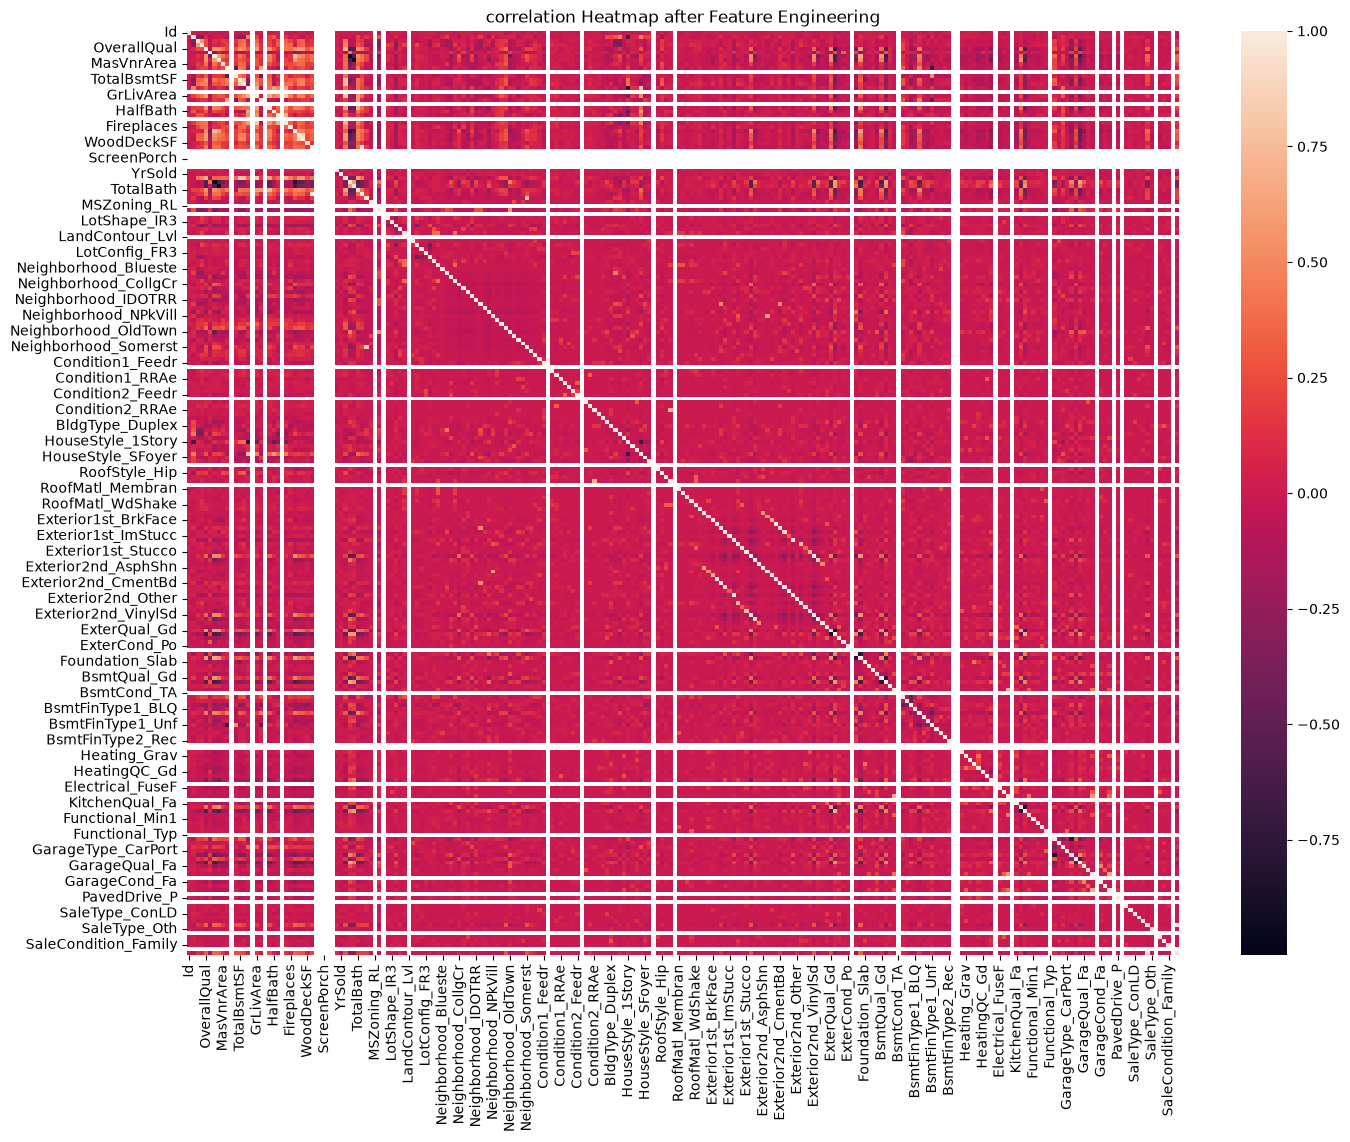

In [28]:
plt.figure(figsize=(16,12))

sns.heatmap(train_scaled.corr())

plt.title("correlation Heatmap after Feature Engineering")
plt.show()

In [29]:
correlation = correlation[correlation > 0.50]

In [30]:
correlation

OverallQual         0.817680
YearBuilt           0.570327
YearRemodAdd        0.552061
TotalBsmtSF         0.645251
1stFlrSF            0.621873
GrLivArea           0.729311
FullBath            0.583994
TotRmsAbvGrd        0.539339
GarageCars          0.675896
GarageArea          0.660029
SalePrice           1.000000
TotalSF             0.821885
TotalBath           0.657381
ExterQual_Gd        0.526232
Foundation_PConc    0.535107
Name: SalePrice, dtype: float64

In [31]:
selected_features = [
    "OverallQual","YearBuilt","YearRemodAdd","TotalBsmtSF","1stFlrSF","GrLivArea",
    "FullBath","TotRmsAbvGrd","GarageCars","GarageArea","TotalSF","TotalBath","ExterQual_Gd","Foundation_PConc"
]

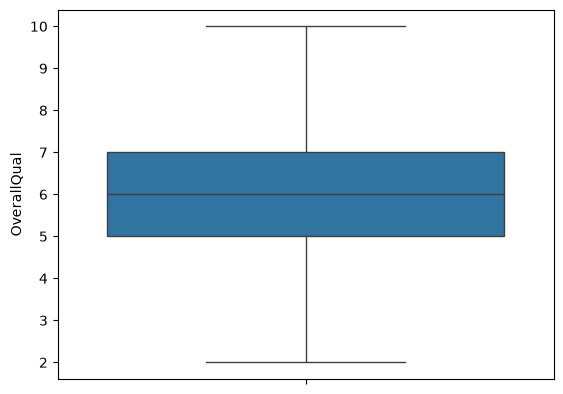

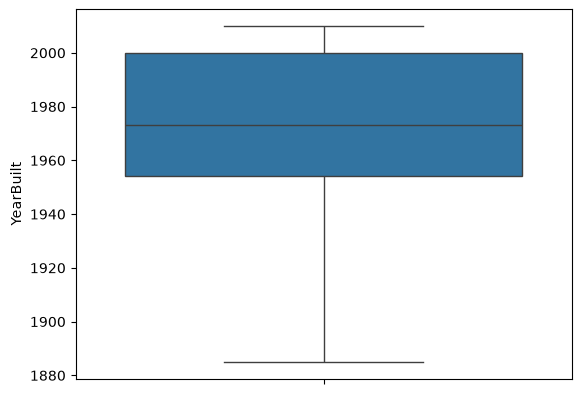

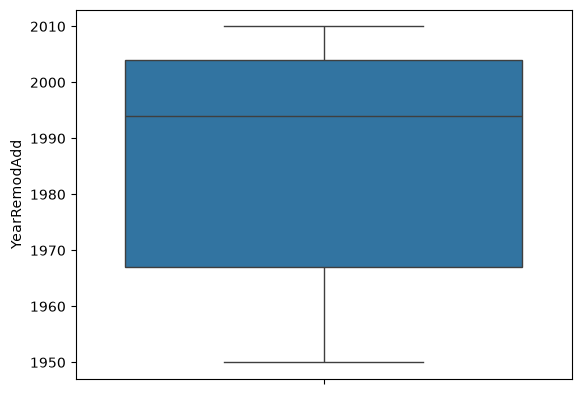

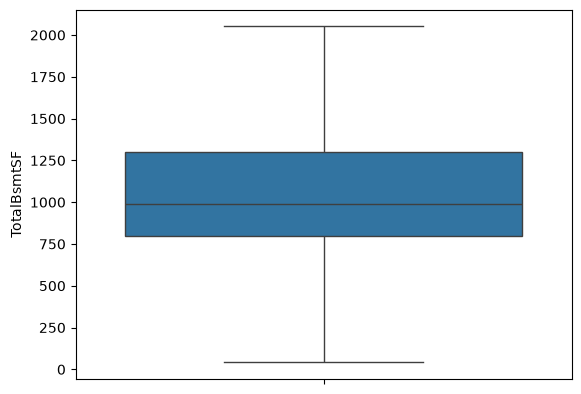

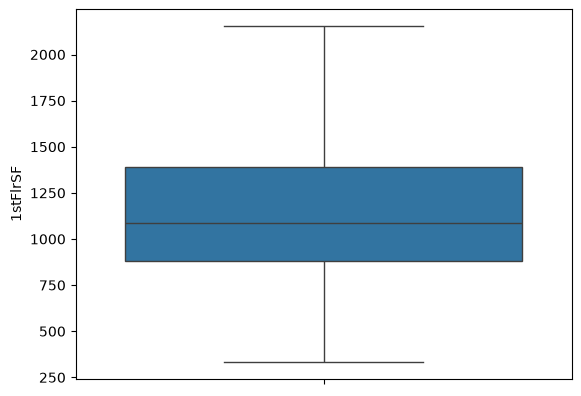

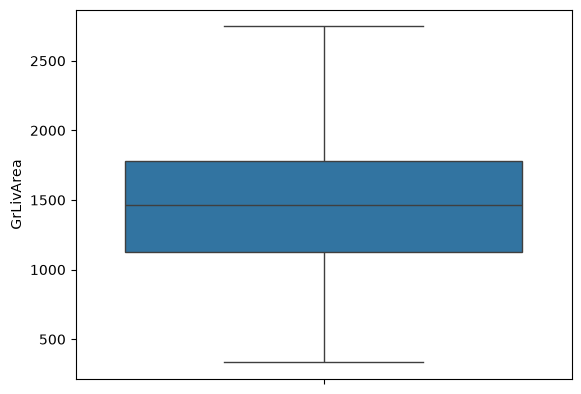

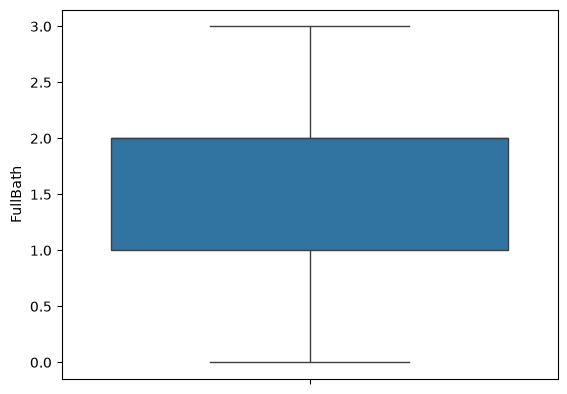

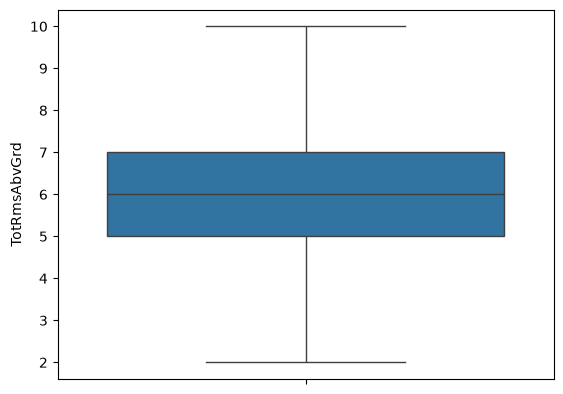

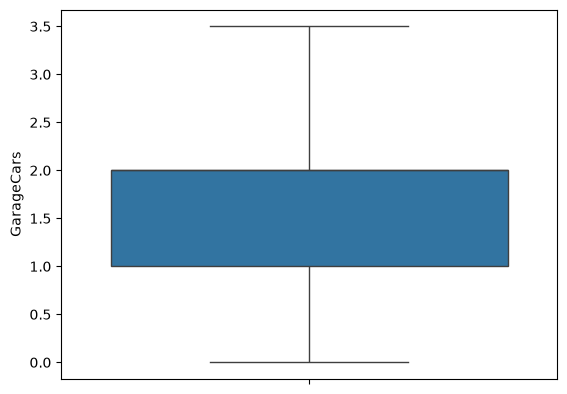

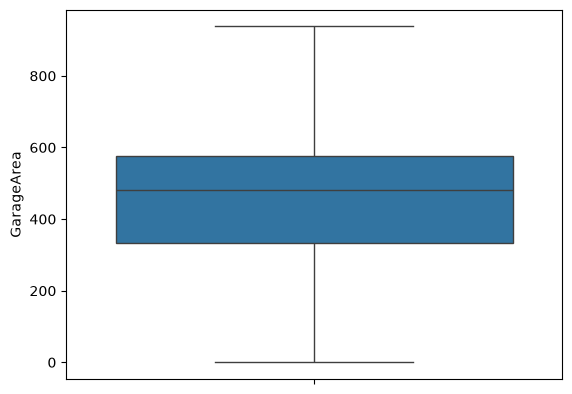

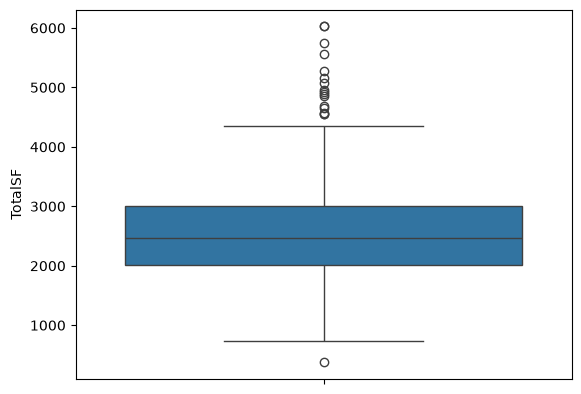

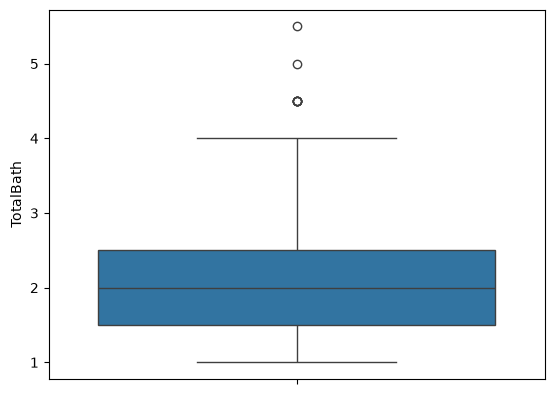

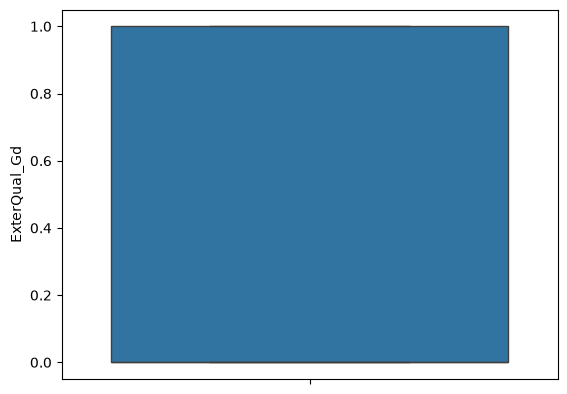

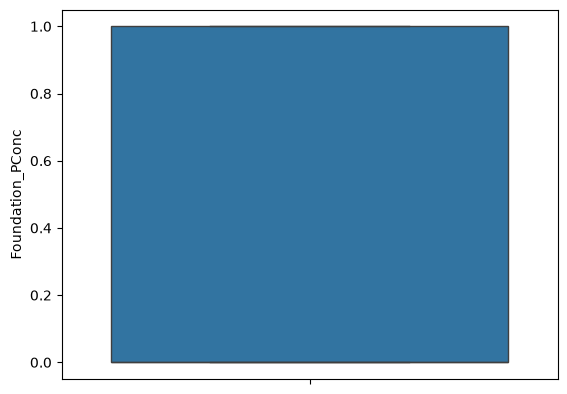

In [32]:
for column in selected_features:

    sns.boxplot(y=train[column])

    plt.show()

In [33]:
missing_values = train_scaled.isnull().sum() 
missing_values = missing_values[missing_values > 0]
missing_index = missing_values.index
missing_values

MSZoning_RL             309
Street_Pave               6
LandContour_Lvl         149
Condition1_Norm         200
Condition2_Norm          15
RoofStyle_Gable         319
RoofMatl_CompShg         26
ExterCond_TA            178
BsmtCond_TA             112
BsmtFinType2_Unf        166
Heating_GasA             32
CentralAir_Y             95
Electrical_SBrkr        125
Functional_Typ          100
GarageQual_TA            68
GarageCond_TA            53
PavedDrive_Y            120
SaleType_WD             193
SaleCondition_Normal    262
dtype: int64

In [34]:
train_scaled

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-1.730865,0.454631,-0.237456,-0.333244,0.652644,-0.564161,1.053246,0.878668,1.230517,0.614224,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
1,-1.728492,-1.143813,0.633321,-0.013189,-0.073068,2.030907,0.156179,-0.429577,-0.809621,1.242296,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
2,-1.726120,0.454631,-0.063300,0.446022,0.652644,-0.564161,0.986797,0.830215,1.157359,0.106224,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
3,-1.723747,0.682185,-0.527714,-0.027104,0.652644,-0.564161,-1.870528,-0.720298,-0.809621,-0.517230,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,NaN,-0.365276
4,-1.721374,0.454631,0.865528,1.283733,1.378355,-0.564161,0.953572,0.733308,1.453554,0.496460,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1.721374,0.454631,-0.411611,-0.481583,-0.073068,-0.564161,0.920347,0.733308,-0.809621,-1.015994,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
1456,1.723747,-1.143813,0.923580,0.981767,-0.073068,0.473866,0.222628,0.151865,1.039095,0.808187,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
1457,1.726120,0.682185,-0.179404,-0.168485,0.652644,2.030907,-1.006686,1.024029,-0.809621,-0.380994,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
1458,1.728492,-1.143813,-0.063300,0.019374,-0.798780,0.473866,-0.707663,0.539493,-0.809621,-0.902848,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276


In [35]:
missing_values.__class__

pandas.Series

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [37]:
train_scaled = train_scaled.fillna(train_scaled.median())

In [38]:
train_scaled.isnull().sum().sum()

np.int64(0)

In [39]:
vif = pd.DataFrame()

vif["Feature"] = train_scaled.columns

vif["VIF"] = [ variance_inflation_factor(train_scaled.values, i) for i in range(train_scaled.shape[1]) ]

c:\Users\Dell\.virtualenvs\Advanced_Regression_Model_Comparison___Opt-lDNjYqWr\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\Dell\.virtualenvs\Advanced_Regression_Model_Comparison___Opt-lDNjYqWr\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Dell\.virtualenvs\Advanced_Regression_Model_Comparison___Opt-lDNjYqWr\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [40]:
vif

,Feature,VIF
0,Id,1.173312
1,MSSubClass,15.786954
2,LotFrontage,2.668480
3,LotArea,3.636655
4,OverallQual,5.243093
...,...,...
230,SaleCondition_AdjLand,1.472638
231,SaleCondition_Alloca,1.375566
232,SaleCondition_Family,1.140551
233,SaleCondition_Normal,0.006286


In [41]:
high_vif = vif[vif["VIF"] > 10]
column_to_remove = high_vif["Feature"]

column_to_remove

1                 MSSubClass
6                  YearBuilt
7               YearRemodAdd
9                 BsmtFinSF1
11                 BsmtUnfSF
12               TotalBsmtSF
13                  1stFlrSF
14                  2ndFlrSF
16                 GrLivArea
17              BsmtFullBath
19                  FullBath
20                  HalfBath
29               OpenPorchSF
36                    YrSold
37                   TotalSF
38                  HouseAge
39                RemodelAge
40                 TotalBath
41              TotalPorchSF
64      Neighborhood_CollgCr
66      Neighborhood_Edwards
71        Neighborhood_NAmes
76      Neighborhood_OldTown
80      Neighborhood_Somerst
104        HouseStyle_1Story
124      Exterior1st_BrkFace
125       Exterior1st_CBlock
126      Exterior1st_CemntBd
127      Exterior1st_HdBoard
129      Exterior1st_MetalSd
130      Exterior1st_Plywood
133      Exterior1st_VinylSd
134      Exterior1st_Wd Sdng
139       Exterior2nd_CBlock
140      Exter

In [42]:
train_scaled = train_scaled.drop( column_to_remove, axis=1)

In [43]:
vif = pd.DataFrame()

vif["Feature"] = train_scaled.columns

vif["VIF"] = [
    variance_inflation_factor(train_scaled.values, i)
    for i in range(train_scaled.shape[1])
]

vif = vif.sort_values(
    by="VIF",
    ascending=False
)

print(vif)

c:\Users\Dell\.virtualenvs\Advanced_Regression_Model_Comparison___Opt-lDNjYqWr\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Dell\.virtualenvs\Advanced_Regression_Model_Comparison___Opt-lDNjYqWr\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


               Feature       VIF
14          GarageCars  7.363748
15          GarageArea  7.000130
116   Foundation_PConc  6.750437
115  Foundation_CBlock  5.820732
3          OverallQual  3.941003
..                 ...       ...
17       EnclosedPorch       NaN
18           3SsnPorch       NaN
19         ScreenPorch       NaN
20            PoolArea       NaN
21             MiscVal       NaN

[185 rows x 2 columns]


In [44]:
vif[vif["VIF"].isna()]

,Feature,VIF
6,BsmtFinSF2,NaN
7,LowQualFinSF,NaN
8,BsmtHalfBath,NaN
10,KitchenAbvGr,NaN
17,EnclosedPorch,NaN
18,3SsnPorch,NaN
19,ScreenPorch,NaN
20,PoolArea,NaN
21,MiscVal,NaN


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ( RandomForestRegressor,GradientBoostingRegressor )
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score

In [47]:
cv_score = cross_val_score(
    LinearRegression(),
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

In [48]:
cv_score

array([0.83531243, 0.83063161, 0.82223671, 0.79677674, 0.84542527])

In [49]:
linear_regression_AvgCV = cv_score.mean()
linear_regression_AvgCV

np.float64(0.8260765514304014)

In [50]:
DecisionTree_CvScore = cross_val_score(
    DecisionTreeRegressor(random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
DecisionTree_CvScore

array([0.6666357 , 0.61173884, 0.65980018, 0.65045616, 0.65765138])

In [51]:
DecisionTree_AvgCV = DecisionTree_CvScore.mean()
DecisionTree_AvgCV

np.float64(0.6492564529708285)

In [52]:
RandomForest_CvScore = cross_val_score(
    RandomForestRegressor(random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
RandomForest_CvScore

array([0.86186201, 0.77932877, 0.84474114, 0.82384975, 0.84243413])

In [53]:
RandomForest_AvgCv = RandomForest_CvScore.mean()
RandomForest_AvgCv

np.float64(0.8304431606521995)

In [54]:
GradientBoosting_CvScore = cross_val_score(
    GradientBoostingRegressor(random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
GradientBoosting_CvScore

array([0.88214565, 0.80109642, 0.85087384, 0.81574916, 0.86392311])

In [55]:
GradientBoosting_AvgCv = GradientBoosting_CvScore.mean()
GradientBoosting_AvgCv

np.float64(0.8427576354915928)

In [56]:
XGB_CvScore = cross_val_score(
    XGBRegressor(random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
XGB_CvScore

array([0.85960815, 0.77971206, 0.86734167, 0.81309047, 0.82846273])

In [57]:
XGB_AvgCv = XGB_CvScore.mean()
XGB_AvgCv

np.float64(0.8296430163990298)

In [58]:
LGBM_CvScore = cross_val_score(
    LGBMRegressor(random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
LGBM_CvScore

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001416 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1324
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 74
[LightGBM] [Info] Start training from score 178266.188437
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000838 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1322
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 74
[LightGBM] [Info] Start training from score 176296.275696
[LightGBM] [Warning] F

array([0.87107558, 0.78164274, 0.86001441, 0.83343587, 0.85251398])

In [59]:
LGBM_AvgCv = LGBM_CvScore.mean()
LGBM_AvgCv

np.float64(0.8397365187451162)

In [60]:
CatBoost_CvScore = cross_val_score(
    CatBoostRegressor(random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
CatBoost_CvScore

Learning rate set to 0.040504
0:	learn: 65249.8530491	total: 147ms	remaining: 2m 26s
1:	learn: 63702.8980262	total: 158ms	remaining: 1m 18s
2:	learn: 62107.6744625	total: 169ms	remaining: 56.2s
3:	learn: 60637.6749622	total: 176ms	remaining: 43.8s
4:	learn: 59220.7887485	total: 182ms	remaining: 36.2s
5:	learn: 57842.5182762	total: 190ms	remaining: 31.5s
6:	learn: 56481.8273504	total: 197ms	remaining: 28s
7:	learn: 55211.2723372	total: 205ms	remaining: 25.5s
8:	learn: 54048.5383043	total: 212ms	remaining: 23.3s
9:	learn: 52833.9311478	total: 216ms	remaining: 21.4s
10:	learn: 51796.5250807	total: 220ms	remaining: 19.8s
11:	learn: 50689.4036491	total: 225ms	remaining: 18.5s
12:	learn: 49774.1134035	total: 228ms	remaining: 17.3s
13:	learn: 48749.9821397	total: 232ms	remaining: 16.3s
14:	learn: 47725.3864048	total: 235ms	remaining: 15.4s
15:	learn: 46797.4241347	total: 238ms	remaining: 14.7s
16:	learn: 45903.5370573	total: 242ms	remaining: 14s
17:	learn: 44971.4412723	total: 246ms	remaining

array([0.89320777, 0.81974155, 0.86581769, 0.82132169, 0.87470682])

In [61]:
CatBoost_AvgCv = LGBM_CvScore.mean()
CatBoost_AvgCv

np.float64(0.8397365187451162)

In [62]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "Average CV Score": [
        linear_regression_AvgCV,
        DecisionTree_AvgCV,
        RandomForest_AvgCv,
        GradientBoosting_AvgCv,
        XGB_AvgCv,
        LGBM_AvgCv,
        CatBoost_AvgCv
    ]
})

results = results.sort_values(
    by="Average CV Score",
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

,Model,Average CV Score
0,Gradient Boosting,0.842758
1,LightGBM,0.839737
2,CatBoost,0.839737
3,Random Forest,0.830443
4,XGBoost,0.829643
5,Linear Regression,0.826077
6,Decision Tree,0.649256


## Hyperparameter

###  Linear Regression

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

parameters = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

grid = GridSearchCV(
    LinearRegression(),
    param_grid=parameters,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'fit_intercept': [True, False], 'positive': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed durin

In [64]:
# Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

parameters = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"]
}

grid = GridSearchCV(
    DecisionTreeRegressor(),
    param_grid=parameters,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbo

In [65]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

parameters = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    param_grid=parameters,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

In [66]:
# Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor

parameters = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    GradientBoostingRegressor(),
    param_grid=parameters,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose 

In [ ]:
# XGBoost Regressor

from xgboost import XGBRegressor

parameters = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid = GridSearchCV(
    XGBRegressor(),
    param_grid=parameters,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

In [ ]:
# LightGBM Regressor

from lightgbm import LGBMRegressor

parameters = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [-1, 5, 10],
    "num_leaves": [31, 50, 100],
    "subsample": [0.8, 1.0]
}

grid = LGBMRegressor(
    XGBRegressor(),
    param_grid=parameters,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

In [ ]:
# CatBoost Regressor

from catboost import CatBoostRegressor

parameters = {
    "iterations": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [1, 3, 5]
}

grid = GridSearchCV(
    CatBoostRegressor(),
    param_grid=parameters,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)